# TP1: Actividad de Demo en Power BI: Análisis de Datos Públicos
---

## Objetivo

* Crear un reporte de visualización interactiva en Power BI utilizando un conjunto de datos públicos disponibles en datos.gob.ar o fuente a elección del estudiante. 
* El objetivo es explorar y visualizar los datos para responder preguntas clave y presentar insights de valor.

## 1. Selecciona el Dataset

Elige un conjunto de datos de tu interés. Puede ser de cualquier temática, como salud, educación, economía, transporte o medio ambiente.

In [24]:
import requests
import pandas as pd
from pandas import json_normalize

response = requests.get('https://www.fruityvice.com/api/fruit/all')
df = pd.DataFrame(response.json())

# expande la columna 'nutrición'
nutricion_df = json_normalize(df['nutritions'])

# Concatena con df (quitando la columna)
df = pd.concat([df.drop(columns=['nutritions']), nutricion_df], axis=1)

df.head()

,name,id,family,order,genus,calories,fat,sugar,carbohydrates,protein
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,81,0.0,18.0,18.0,0.0
1,Strawberry,3,Rosaceae,Rosales,Fragaria,29,0.4,5.4,5.5,0.8
2,Banana,1,Musaceae,Zingiberales,Musa,96,0.2,17.2,22.0,1.0
3,Tomato,5,Solanaceae,Solanales,Solanum,74,0.2,2.6,3.9,0.9
4,Pear,4,Rosaceae,Rosales,Pyrus,57,0.1,10.0,15.0,0.4


* Proporciona datos sobre frutas:

| Campo          | Tipo    | Descripción                                      |
|----------------|---------|--------------------------------------------------|
| name           | Cadena  | Nombre de la fruta.                              |
| id             | Entero  | Identificación de la fruta.                      |
| family         | Cadena  | Familia de la fruta.                             |
| order          | Cadena  | Orden de la fruta.                               |
| genus          | Cadena  | Género del fruto.                                |
| calories       | Entero  | Calorías de la fruta (por 100 g) en gramos.      |
| fat            | Entero  | Grasa de la fruta (por 100 g) en gramos.         |
| sugar          | Entero  | Azúcares de la fruta (por 100 g) en gramos.      |
| carbohydrates  | Entero  | Carbohidratos de la fruta (por 100 g) en gramos. |
| protein        | Entero  | Proteína de la fruta (por 100 g) en gramos.      |

## 2. Importa el dataset seleccionado en Power BI

* Power BI Desktop no funciona nativamente en macOS
* Alternativa: servicio web de Power BI (app.powerbi.com)
* Agregar datos para empezar a crear un informe
* Conectarse a un origen de datos API web con URL: https://www.fruityvice.com/api/fruit/all

## 3. Creación de Visualizaciones

Crea al menos tres visualizaciones diferentes para representar los datos. Puedes incluir:
* Un gráfico de barras o columnas para comparar categorías.
* Un gráfico de líneas para mostrar tendencias en el tiempo.
* Un mapa si los datos incluyen información geográfica.

### Gráfico de barras (comparación de categorías)

* **Objetivo**: comparar el contenido de calorías por fruta.
* **Configuración**:
    * Eje X: name
    * Eje Y: calories
* **Resultado esperado**: barras que muestran qué frutas son más calóricas.

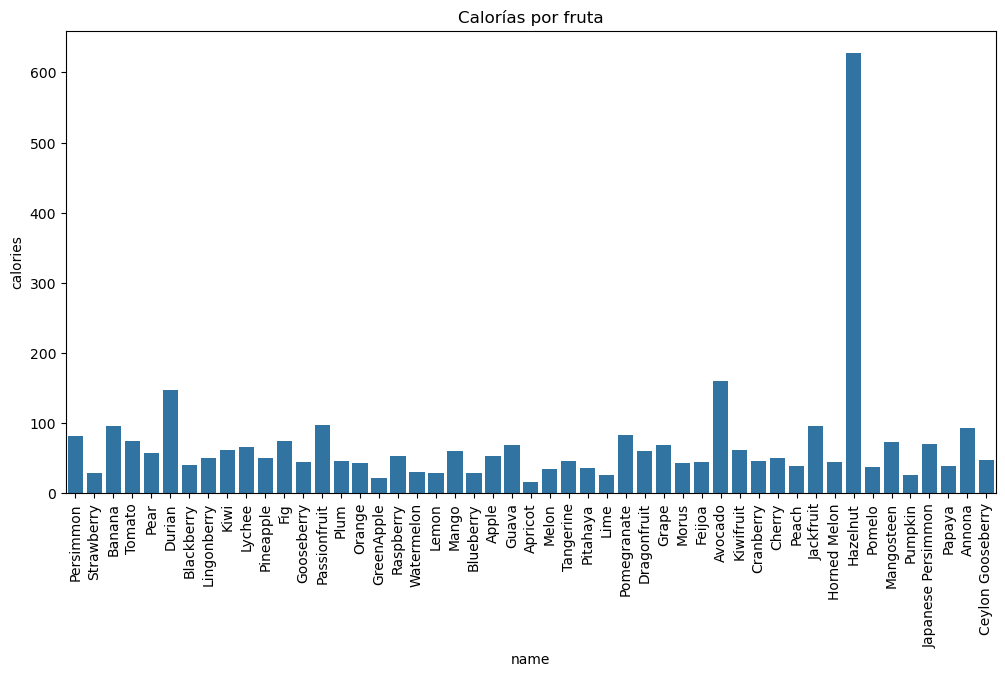

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x='name', y='calories', data=df)
plt.xticks(rotation=90)
plt.title('Calorías por fruta')
plt.show()

**Análisis**:
* La avellana (Hazelnut) destaca con 628 calorías por 100 g, muy por encima del resto.
* El aguacate (Avocado) también es notable con 160 calorías, principalmente por su alto contenido de grasa saludable.
* En contraste, frutas como el albaricoque (Apricot) y la manzana verde (GreenApple) tienen valores muy bajos (15 y 21 calorías respectivamente).

### Gráfico de líneas (tendencia nutricional)

* **Objetivo**: mostrar cómo varía el contenido de azúcar entre las frutas ordenadas por su id.
* **Configuración**:
    * Eje X: id (puede usarse como orden de referencia)
    * Eje Y: sugar
* **Resultado esperado**: una línea que refleja la tendencia de azúcar en las frutas, destacando cuáles tienen picos.

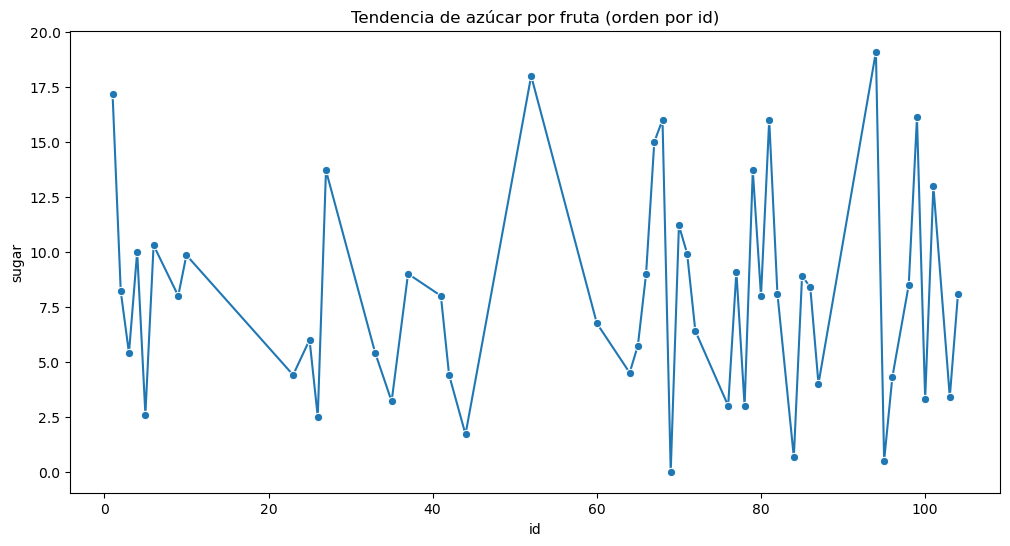

In [27]:
plt.figure(figsize=(12,6))
sns.lineplot(x='id', y='sugar', data=df, marker='o')
plt.title('Tendencia de azúcar por fruta (orden por id)')
plt.show()

**Análisis**
* Frutas como el caqui (Persimmon) y el jackfruit tienen niveles elevados de azúcar (18–19 g).
* Otras, como la grosella (Gooseberry), muestran valores sorprendentemente bajos (0 g de azúcar), lo cual es un patrón inesperado.

### Gráfico de dispersión (scatter plot)

* **Objetivo**: analizar la relación entre dos variables nutricionales, por ejemplo azúcar vs calorías.
* **Configuración**: ubicar cada fruta como un punto en el plano
    * Eje X: sugar
    * Eje Y: calories 
* **Resultado esperado**: ver si las frutas con más azúcar tienden a tener más calorías o si hay excepciones.

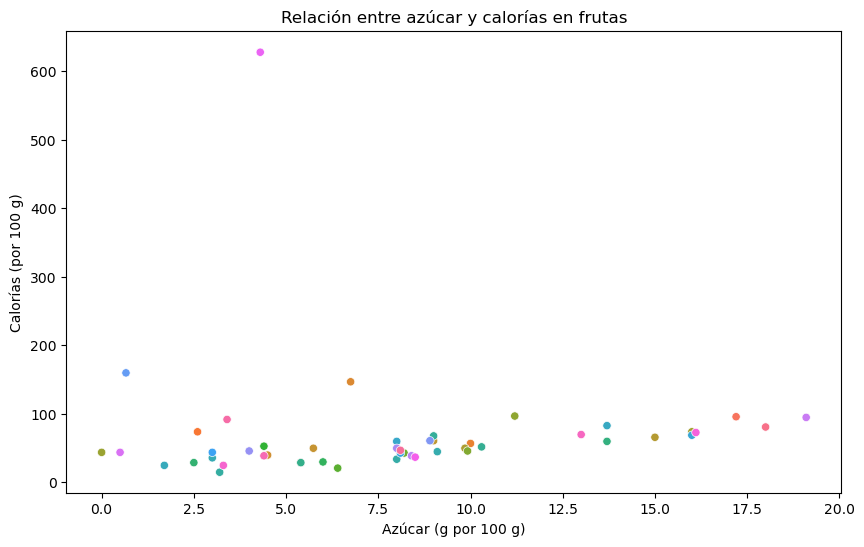

In [28]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='sugar',
    y='calories',
    data=df,
    hue='name',  # cada fruta con color distinto
    legend=False
)

plt.title('Relación entre azúcar y calorías en frutas')
plt.xlabel('Azúcar (g por 100 g)')
plt.ylabel('Calorías (por 100 g)')
plt.show()

**Análisis**:
* Frutas como Hazelnut aparecen con muchas calorías pero poco azúcar (por su grasa).
* Frutas como Jackfruit y Persimmon tienen alto azúcar y también calorías.
* Frutas como la sandía tienen pocas calorías y azúcar moderado.

## 4. Analiza los resultados obtenidos y resume algunos aspectos importantes de lo obtenido

Por ejemplo, podrías resaltar tendencias notables, patrones inesperados o comparaciones significativas.

**Comparaciones significativas**
* Algunas frutas con bajo aporte calórico (ej. sandía con 30 calorías) siguen teniendo un contenido de azúcar moderado (6 g), lo que indica que no siempre las calorías dependen del azúcar.
* El aguacate es un caso particular: alto en calorías pero con muy poco azúcar, lo que lo diferencia claramente de frutas dulces como el mango o la uva.

**Resumen**
* Frutas secas y oleaginosas (avellana, aguacate) concentran más calorías y grasas.
* Frutas frescas y jugosas (sandía, melón, manzana verde) son bajas en calorías y grasas, pero pueden variar mucho en azúcar.
* Se observa un patrón general: la mayoría de las frutas son bajas en grasa, y las diferencias principales entre ellas provienen del contenido de azúcar y carbohidratos.

## Informe en Power BI

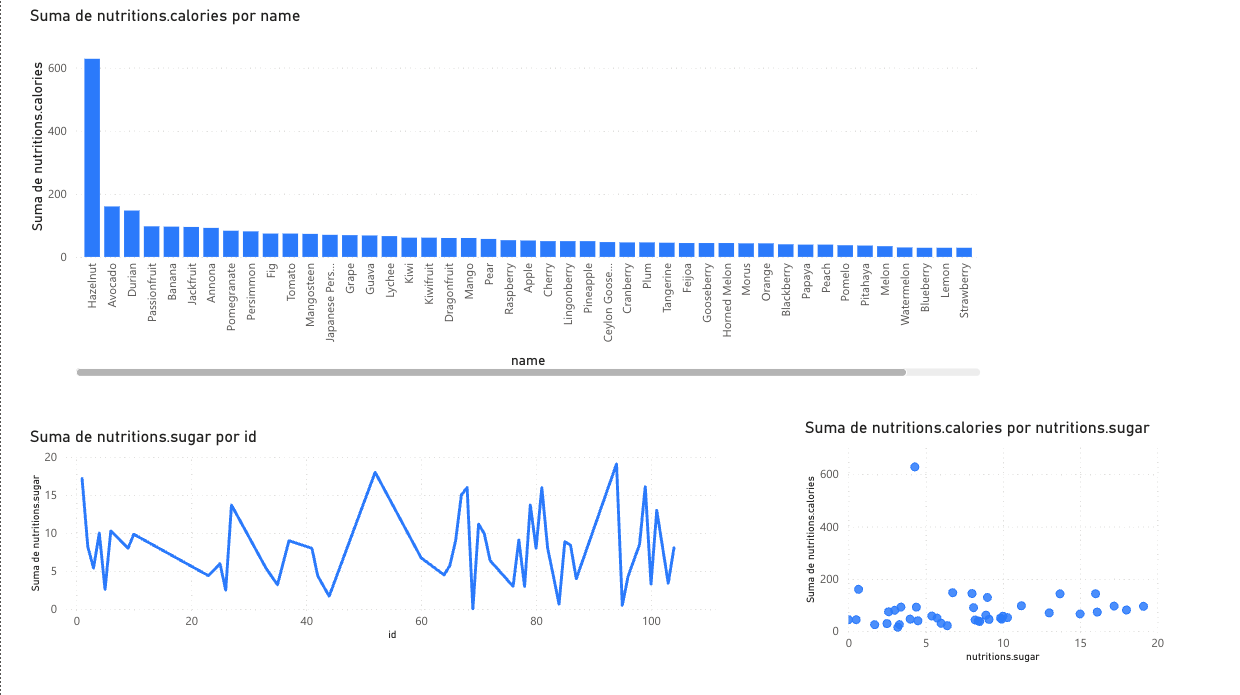